# Mini Project Overview

### General Details

Date: 2026-09-13  
Student Name: Gautham VR  
Batch / Cohort:April-October(Afternoon) 
Project Title: Customer Churn Prediction  
Project Type: Classification  

---

### Tools, Libraries & Frameworks Used

Languages: Python
Data Manipulation & Analysis: Pandas, NumPy
Visualization: Matplotlib
Machine Learning / Modeling: Scikit-Learn (KNN, Logistic Regression, Random Forest)
Environment / Tools: Jupyter Notebook, Git, GitHub

---

### Project Breakdown & Execution

What I Worked On: Built a binary classification model to predict customer churn using tenure, total usage and support ticket count. The project includes data preparation, exploratory data analysis, model training and evaluation. The main evaluation metrics are accuracy, precision, recall and F1-score.

What I Completed:

Data Cleaning & Feature Engineering
Exploratory Data Analysis (EDA)
Model Training
Final Evaluation & Model Selection

Currently Working On: Project documentation

---

### Challenges & Solutions

Blocker / Challenge 1: The churn and non-churn classes were imbalanced.
How I Addressed It: Compared classification metrics and tested a balanced Logistic Regression model using class_weight="balanced".

Blocker / Challenge 2: Different customer data sources had to be combined.
How I Addressed It: Merged account, usage and support-ticket data using account_id.

Blocker / Challenge 3: The tested models produced different results.
How I Addressed It: Compared KNN, Logistic Regression and Random Forest using accuracy, precision, recall and F1-score.

---

### Deliverables & Socials

Project / GitHub Link: [Insert GitHub Repo Link]
LinkedIn Post Activity: Pending


In [1]:
import pandas as pd
import numpy as np

In [2]:
# ============================================================
# 2. LOAD DATA
# ============================================================

account_master = pd.read_csv("account_master.csv")
usage_logs = pd.read_csv("usage_logs.csv")
support_tickets = pd.read_csv("support_tickets.csv")
churned_labeled = pd.read_csv("churned_labeled.csv")
churned_to_predict = pd.read_csv("churned_to_predict.csv")

print("--- Data Loaded Successfully ---")

print("Account Master:", account_master.shape)
print("Usage Logs:", usage_logs.shape)
print("Support Tickets:", support_tickets.shape)
print("Churned Labeled:", churned_labeled.shape)
print("Churned To Predict:", churned_to_predict.shape)

--- Data Loaded Successfully ---
Account Master: (392, 5)
Usage Logs: (4715, 5)
Support Tickets: (1161, 5)
Churned Labeled: (334, 2)
Churned To Predict: (58, 1)


In [3]:
# ============================================================
# 3. DATA PREPARATION / AGGREGATION
# ============================================================

# Calculate total usage for each account
usage_summary = (
    usage_logs
    .groupby("account_id")
    .size()
    .reset_index(name="total_usage")
)

# Calculate number of support tickets for each account
tickets_summary = (
    support_tickets
    .groupby("account_id")
    .size()
    .reset_index(name="ticket_count")
)

print("--- Aggregation Completed ---")

print("\nUsage Summary:")
print(usage_summary.head())

print("\nTicket Summary:")
print(tickets_summary.head())

--- Aggregation Completed ---

Usage Summary:
  account_id  total_usage
0  CUST-0001           14
1  CUST-0002           12
2  CUST-0003            6
3  CUST-0004           10
4  CUST-0005           18

Ticket Summary:
  account_id  ticket_count
0  CUST-0001             5
1  CUST-0002             3
2  CUST-0003             5
3  CUST-0004             5
4  CUST-0006             4


In [4]:
# ============================================================
# 4. MERGE DATASETS
# ============================================================

final_data = (
    account_master
    .merge(usage_summary, on="account_id", how="left")
    .merge(tickets_summary, on="account_id", how="left")
    .merge(churned_labeled, on="account_id", how="inner")
)

print("--- Datasets Merged Successfully ---")
print("Final Dataset Shape:", final_data.shape)

print("\nFirst 5 Rows:")
print(final_data.head())

--- Datasets Merged Successfully ---
Final Dataset Shape: (334, 8)

First 5 Rows:
  account_id plan_tier  tenure_months region referral_source  total_usage   
0  CUST-0001      Free             53     EU         Partner           14  \
1  CUST-0002  Business              4   APAC         Organic           12   
2  CUST-0003       Pro             49  LATAM        Referral            6   
3  CUST-0004       Pro             18     EU        Referral           10   
4  CUST-0005       Pro             44    NaN         Organic           18   

   ticket_count churned  
0           5.0      No  
1           3.0      No  
2           5.0      No  
3           5.0      No  
4           NaN      No  


In [5]:
# ============================================================
# 5. HANDLE MISSING VALUES
# ============================================================

print("--- Missing Values Before Handling ---")
print(final_data.isnull().sum())

# Replace missing values with 0
final_data.fillna(0, inplace=True)

print("\n--- Missing Values After Handling ---")
print(final_data.isnull().sum())

--- Missing Values Before Handling ---
account_id          0
plan_tier           0
tenure_months       0
region             87
referral_source     8
total_usage         0
ticket_count       41
churned             0
dtype: int64

--- Missing Values After Handling ---
account_id         0
plan_tier          0
tenure_months      0
region             0
referral_source    0
total_usage        0
ticket_count       0
churned            0
dtype: int64


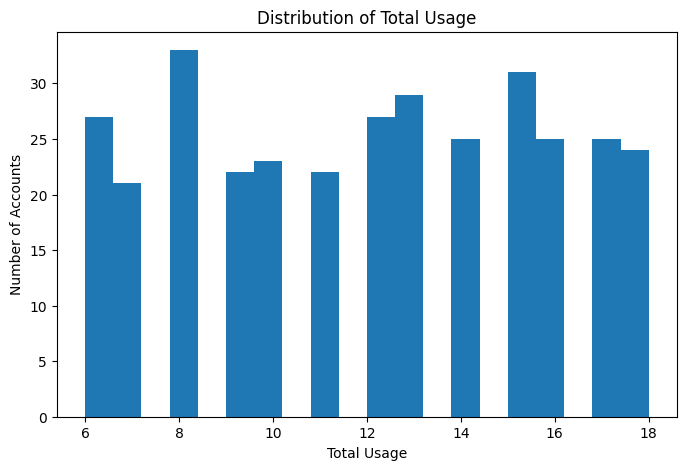

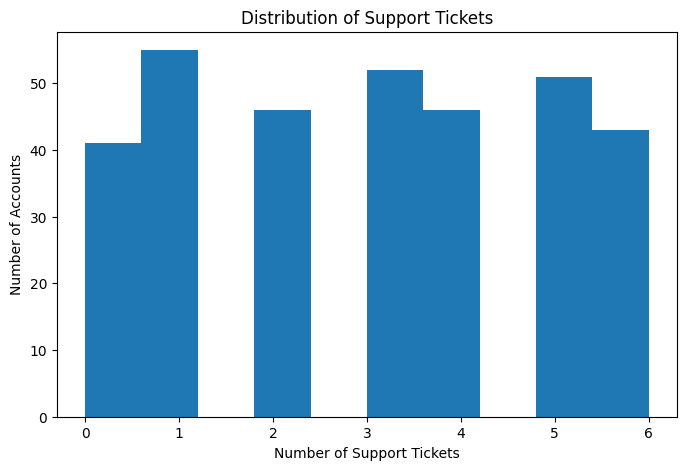

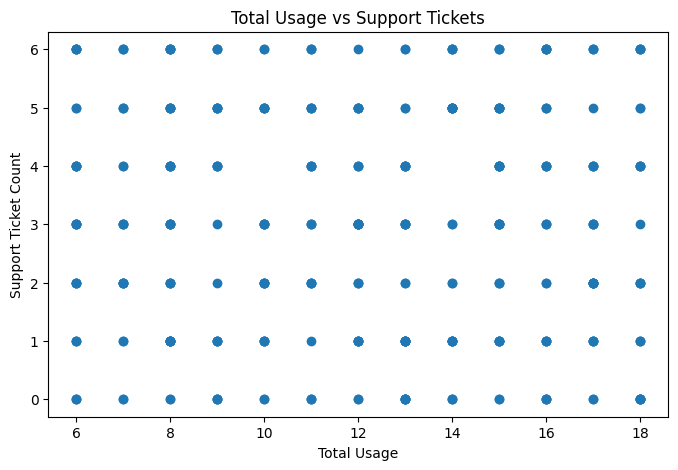

In [6]:
# ============================================================
# 6. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

import matplotlib.pyplot as plt

# EDA Chart 1: Distribution of Total Usage
plt.figure(figsize=(8, 5))
plt.hist(final_data["total_usage"], bins=20)
plt.title("Distribution of Total Usage")
plt.xlabel("Total Usage")
plt.ylabel("Number of Accounts")
plt.show()


# EDA Chart 2: Distribution of Support Tickets
plt.figure(figsize=(8, 5))
plt.hist(final_data["ticket_count"], bins=10)
plt.title("Distribution of Support Tickets")
plt.xlabel("Number of Support Tickets")
plt.ylabel("Number of Accounts")
plt.show()


# EDA Chart 3: Total Usage vs Support Tickets
plt.figure(figsize=(8, 5))
plt.scatter(
    final_data["total_usage"],
    final_data["ticket_count"]
)
plt.title("Total Usage vs Support Tickets")
plt.xlabel("Total Usage")
plt.ylabel("Support Ticket Count")
plt.show()

--- Churn Target Distribution ---
churned
No     251
Yes     83
Name: count, dtype: int64


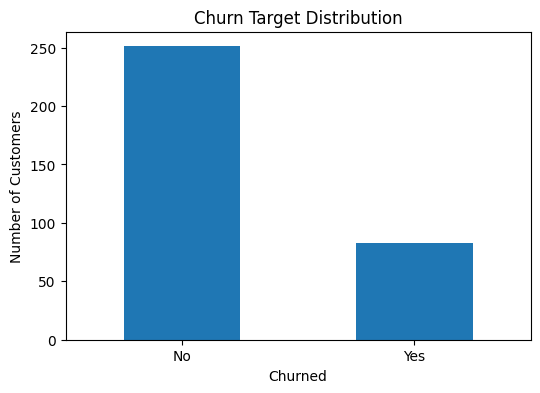

In [7]:
print("--- Churn Target Distribution ---")

print(churned_labeled["churned"].value_counts())

plt.figure(figsize=(6, 4))

churned_labeled["churned"].value_counts().plot(
    kind="bar"
)

plt.title("Churn Target Distribution")
plt.xlabel("Churned")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.show()

In [8]:
# ============================================================
# 9. BASELINE MODEL
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

# Features and target
X = final_data[
    ["tenure_months", "total_usage", "ticket_count"]
]

y = final_data["churned"]

# Convert Yes/No to 1/0
y = y.map({"No": 0, "Yes": 1})

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Baseline model
baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X_train, y_train)

# Prediction
baseline_pred = baseline.predict(X_test)

# Accuracy
baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

print("--- Baseline Model ---")
print("Baseline Accuracy:", round(baseline_accuracy * 100, 2), "%")

--- Baseline Model ---
Baseline Accuracy: 75.25 %


In [9]:
# ============================================================
# 10. KNN MODEL
# ============================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# KNN model
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

# Prediction
knn_pred = knn.predict(X_test_scaled)

# Accuracy
knn_accuracy = accuracy_score(y_test, knn_pred)

print("--- KNN Model ---")
print("KNN Accuracy:", round(knn_accuracy * 100, 2), "%")

--- KNN Model ---
KNN Accuracy: 72.28 %


--- Classification Report ---
              precision    recall  f1-score   support

    No Churn       0.75      0.95      0.84        76
       Churn       0.20      0.04      0.07        25

    accuracy                           0.72       101
   macro avg       0.47      0.49      0.45       101
weighted avg       0.61      0.72      0.65       101

--- Confusion Matrix ---
[[72  4]
 [24  1]]


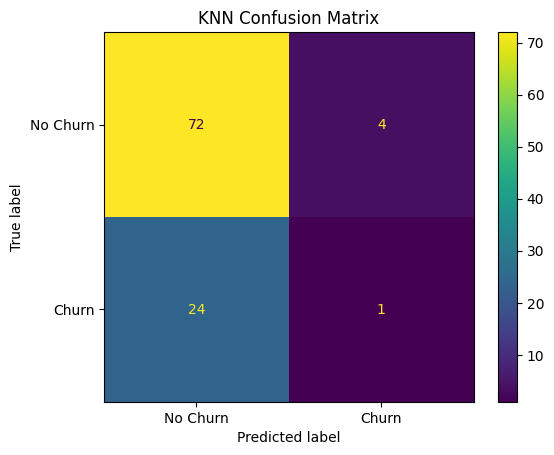

In [10]:
# ============================================================
# 11. KNN MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Classification Report
print("--- Classification Report ---")

print(
    classification_report(
        y_test,
        knn_pred,
        target_names=["No Churn", "Churn"]
    )
)


# Confusion Matrix
cm = confusion_matrix(y_test, knn_pred)

print("--- Confusion Matrix ---")
print(cm)


# Confusion Matrix Visualization
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("KNN Confusion Matrix")
plt.show()

In [11]:
# ============================================
# LOGISTIC REGRESSION MODEL
# ============================================

from sklearn.linear_model import LogisticRegression

# Create model
logistic_model = LogisticRegression(max_iter=1000)

# Train model
logistic_model.fit(X_train_scaled, y_train)

# Prediction
logistic_pred = logistic_model.predict(X_test_scaled)

# Accuracy
logistic_accuracy = accuracy_score(y_test, logistic_pred)

print("--- Logistic Regression Model ---")
print("Logistic Regression Accuracy:",
      round(logistic_accuracy * 100, 2), "%")

--- Logistic Regression Model ---
Logistic Regression Accuracy: 75.25 %


In [12]:
# ============================================================
# MODEL COMPARISON
# ============================================================

print("========== MODEL COMPARISON ==========")

print("Baseline Accuracy          :", round(baseline_accuracy * 100, 2), "%")
print("KNN Accuracy               :", round(knn_accuracy * 100, 2), "%")
print("Logistic Regression Accuracy:", round(logistic_accuracy * 100, 2), "%")

========== MODEL COMPARISON ==========
Baseline Accuracy          : 75.25 %
KNN Accuracy               : 72.28 %
Logistic Regression Accuracy: 75.25 %


========== LOGISTIC REGRESSION EVALUATION ==========

Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86        76
           1       0.00      0.00      0.00        25

    accuracy                           0.75       101
   macro avg       0.38      0.50      0.43       101
weighted avg       0.57      0.75      0.65       101


Confusion Matrix:
[[76  0]
 [25  0]]


c:\Users\admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

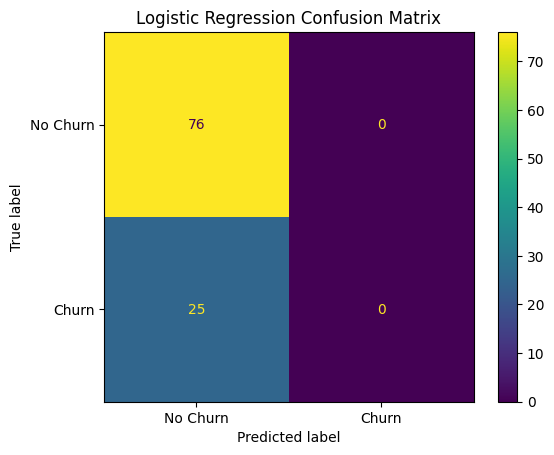

In [13]:
# ============================================================
# LOGISTIC REGRESSION - DETAILED EVALUATION
# ============================================================

print("========== LOGISTIC REGRESSION EVALUATION ==========")

print("\nClassification Report:")
print(classification_report(y_test, logistic_pred))

# Confusion Matrix
logistic_cm = confusion_matrix(y_test, logistic_pred)

print("\nConfusion Matrix:")
print(logistic_cm)

# Display Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [14]:
# ============================================================
# LOGISTIC REGRESSION - CLASSIFICATION REPORT
# ============================================================

print("========== LOGISTIC REGRESSION CLASSIFICATION REPORT ==========")

print(classification_report(
    y_test,
    logistic_pred,
    target_names=["No Churn", "Churn"],
    zero_division=0
))

========== LOGISTIC REGRESSION CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

    No Churn       0.75      1.00      0.86        76
       Churn       0.00      0.00      0.00        25

    accuracy                           0.75       101
   macro avg       0.38      0.50      0.43       101
weighted avg       0.57      0.75      0.65       101



In [15]:
# ============================================================
# KNN - CLASSIFICATION REPORT
# ============================================================

print("========== KNN CLASSIFICATION REPORT ==========")

print(classification_report(
    y_test,
    knn_pred,
    target_names=["No Churn", "Churn"],
    zero_division=0
))

========== KNN CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

    No Churn       0.75      0.95      0.84        76
       Churn       0.20      0.04      0.07        25

    accuracy                           0.72       101
   macro avg       0.47      0.49      0.45       101
weighted avg       0.61      0.72      0.65       101



In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Improved Logistic Regression
balanced_model = LogisticRegression(
    class_weight="balanced",
    random_state=42
)

# Train
balanced_model.fit(X_train_scaled, y_train)

# Prediction
balanced_pred = balanced_model.predict(X_test_scaled)

# Accuracy
balanced_accuracy = accuracy_score(y_test, balanced_pred)

print("=== Balanced Logistic Regression ===")
print("Accuracy:", round(balanced_accuracy * 100, 2), "%")

=== Balanced Logistic Regression ===
Accuracy: 58.42 %


In [17]:
print("=== BALANCED LOGISTIC REGRESSION CLASSIFICATION REPORT ===")

print(classification_report(
    y_test,
    balanced_pred,
    target_names=["No Churn", "Churn"],
    zero_division=0
))

=== BALANCED LOGISTIC REGRESSION CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    No Churn       0.78      0.62      0.69        76
       Churn       0.29      0.48      0.36        25

    accuracy                           0.58       101
   macro avg       0.54      0.55      0.53       101
weighted avg       0.66      0.58      0.61       101



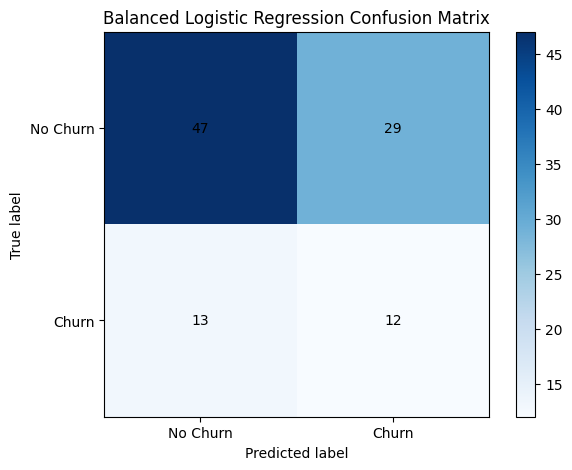

In [29]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, balanced_pred)

plt.figure(figsize=(7, 5))

plt.imshow(cm, interpolation="nearest", cmap="Blues")

plt.title("Balanced Logistic Regression Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])

# Show values inside the graph
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.colorbar()
plt.show()

In [18]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Prediction
rf_pred = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("=== Random Forest Model ===")
print("Accuracy:", round(rf_accuracy * 100, 2), "%")

=== Random Forest Model ===
Accuracy: 76.24 %


[[73  3]
 [21  4]]


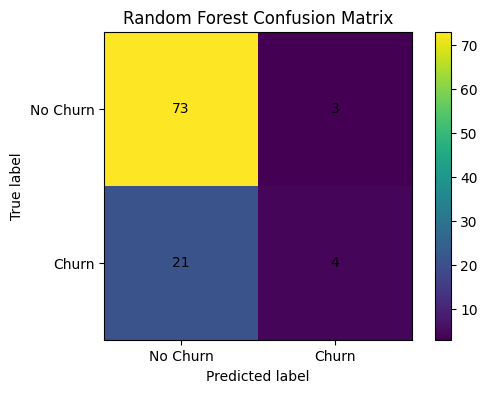

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

plt.figure(figsize=(6, 4))

plt.imshow(rf_cm)

plt.colorbar()

plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Random Forest Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(j, i, rf_cm[i, j],
                 ha="center",
                 va="center")

plt.show()

In [20]:
from sklearn.metrics import classification_report

print("=== RANDOM FOREST CLASSIFICATION REPORT ===")

print(classification_report(
    y_test,
    rf_pred,
    target_names=["No Churn", "Churn"],
    zero_division=0
))

=== RANDOM FOREST CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    No Churn       0.78      0.96      0.86        76
       Churn       0.57      0.16      0.25        25

    accuracy                           0.76       101
   macro avg       0.67      0.56      0.55       101
weighted avg       0.73      0.76      0.71       101



In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

model_results = pd.DataFrame({
    "Model": [
        "KNN",
        "Logistic Regression",
        "Random Forest"
    ],
    
    "Accuracy": [
        knn_accuracy,
        logistic_accuracy,
        rf_accuracy
    ],
    
    "Churn Precision": [
        precision_score(y_test, knn_pred, zero_division=0),
        precision_score(y_test, logistic_pred, zero_division=0),
        precision_score(y_test, rf_pred, zero_division=0)
    ],
    
    "Churn Recall": [
        recall_score(y_test, knn_pred, zero_division=0),
        recall_score(y_test, logistic_pred, zero_division=0),
        recall_score(y_test, rf_pred, zero_division=0)
    ],
    
    "Churn F1": [
        f1_score(y_test, knn_pred, zero_division=0),
        f1_score(y_test, logistic_pred, zero_division=0),
        f1_score(y_test, rf_pred, zero_division=0)
    ]
})

model_results

,Model,Accuracy,Churn Precision,Churn Recall,Churn F1
0,KNN,0.722772,0.200000,0.04,0.066667
1,Logistic Regression,0.752475,0.000000,0.00,0.000000
2,Random Forest,0.762376,0.571429,0.16,0.250000


In [22]:
# ============================================
# FINAL CHURN PREDICTION
# ============================================

# Load accounts that need prediction
churned_to_predict = pd.read_csv("churned_to_predict.csv")

# Start with account IDs
prediction_data = churned_to_predict[["account_id"]].copy()


# ============================================
# Add tenure information
# ============================================

prediction_data = prediction_data.merge(
    account_master[["account_id", "tenure_months"]],
    on="account_id",
    how="left"
)


# ============================================
# Add total usage
# ============================================

prediction_data = prediction_data.merge(
    usage_summary,
    on="account_id",
    how="left"
)


# ============================================
# Add ticket count
# ============================================

support_tickets = pd.read_csv("support_tickets.csv")

ticket_summary = (
    support_tickets
    .groupby("account_id")
    .size()
    .reset_index(name="ticket_count")
)

prediction_data = prediction_data.merge(
    ticket_summary,
    on="account_id",
    how="left"
)


# ============================================
# Missing values = 0
# ============================================

prediction_data["total_usage"] = prediction_data["total_usage"].fillna(0)
prediction_data["ticket_count"] = prediction_data["ticket_count"].fillna(0)


# ============================================
# Use exactly the same features as training
# ============================================

X_new = prediction_data[X_train.columns]

print("Prediction Data:")
print(X_new.head())

print("\nPrediction Columns:")
print(list(X_new.columns))


# ============================================
# PREDICTION USING RANDOM FOREST
# ============================================

final_prediction = rf_model.predict(X_new)


# Add prediction to original dataframe
churned_to_predict["Predicted_Churn"] = final_prediction


# Convert 0/1 into readable labels
churned_to_predict["Predicted_Churn"] = (
    churned_to_predict["Predicted_Churn"]
    .map({
        0: "No Churn",
        1: "Churn"
    })
)


print("\nPrediction Counts:")
print(churned_to_predict["Predicted_Churn"].value_counts())

Prediction Data:
   tenure_months  total_usage  ticket_count
0             59           16           5.0
1             25            9           0.0
2             12           13           6.0
3              7            9           0.0
4              4           11           2.0

Prediction Columns:
['tenure_months', 'total_usage', 'ticket_count']

Prediction Counts:
Predicted_Churn
No Churn    52
Churn        6
Name: count, dtype: int64


In [23]:
print(churned_to_predict.columns)
print(churned_to_predict.head())

Index(['account_id', 'Predicted_Churn'], dtype='object')
  account_id Predicted_Churn
0  CUST-0029        No Churn
1  CUST-0040        No Churn
2  CUST-0041           Churn
3  CUST-0042        No Churn
4  CUST-0059           Churn


In [24]:
print("TRAINING COLUMNS:")
print(list(X_train.columns))

print("\nPREDICTION DATA COLUMNS:")
print(list(churned_to_predict.columns))

TRAINING COLUMNS:
['tenure_months', 'total_usage', 'ticket_count']

PREDICTION DATA COLUMNS:
['account_id', 'Predicted_Churn']


In [25]:
# ==========================================
# PREPARE NEW DATA FOR FINAL PREDICTION
# ==========================================

# Create usage count for each account
usage_summary = (
    usage_logs.groupby("account_id")
    .size()
    .reset_index(name="total_usage")
)

# Create ticket count for each account
tickets_summary = (
    support_tickets.groupby("account_id")
    .size()
    .reset_index(name="ticket_count")
)

# Merge prediction accounts with account master
predict_processed = (
    churned_to_predict
    .merge(account_master[["account_id", "tenure_months"]], 
           on="account_id", how="left")
    .merge(usage_summary, on="account_id", how="left")
    .merge(tickets_summary, on="account_id", how="left")
)

# Fill missing values
predict_processed["total_usage"] = predict_processed["total_usage"].fillna(0)
predict_processed["ticket_count"] = predict_processed["ticket_count"].fillna(0)

# Select the same features used for training
X_new = predict_processed[
    ["tenure_months", "total_usage", "ticket_count"]
]

print("NEW DATA READY FOR PREDICTION")
print(X_new.head())
print("\nShape:", X_new.shape)

NEW DATA READY FOR PREDICTION


   tenure_months  total_usage  ticket_count
0             59           16           5.0
1             25            9           0.0
2             12           13           6.0
3              7            9           0.0
4              4           11           2.0

Shape: (58, 3)


In [26]:
# ==========================================
# FINAL CHURN PREDICTION
# ==========================================

# Predict using Random Forest
final_prediction = rf_model.predict(X_new)

# Convert 0/1 into labels
churned_to_predict["Predicted_Churn"] = final_prediction

churned_to_predict["Predicted_Churn"] = (
    churned_to_predict["Predicted_Churn"]
    .map({0: "No Churn", 1: "Churn"})
)

# Display predictions
print("=== FINAL CHURN PREDICTIONS ===")
print(churned_to_predict[["account_id", "Predicted_Churn"]])

# Count predictions
print("\nPrediction Summary:")
print(churned_to_predict["Predicted_Churn"].value_counts())

=== FINAL CHURN PREDICTIONS ===
   account_id Predicted_Churn
0   CUST-0029        No Churn
1   CUST-0040        No Churn
2   CUST-0041           Churn
3   CUST-0042        No Churn
4   CUST-0059           Churn
5   CUST-0076        No Churn
6   CUST-0082        No Churn
7   CUST-0083        No Churn
8   CUST-0096        No Churn
9   CUST-0103        No Churn
10  CUST-0108           Churn
11  CUST-0118        No Churn
12  CUST-0119        No Churn
13  CUST-0132        No Churn
14  CUST-0134        No Churn
15  CUST-0141        No Churn
16  CUST-0143        No Churn
17  CUST-0157           Churn
18  CUST-0158        No Churn
19  CUST-0164        No Churn
20  CUST-0166        No Churn
21  CUST-0172        No Churn
22  CUST-0174        No Churn
23  CUST-0178        No Churn
24  CUST-0219        No Churn
25  CUST-0230        No Churn
26  CUST-0232        No Churn
27  CUST-0243        No Churn
28  CUST-0244        No Churn
29  CUST-0248        No Churn
30  CUST-0252           Churn
31  CUST

In [27]:
# ==========================================
# SAVE FINAL PREDICTIONS
# ==========================================

output_file = "final_churn_predictions.csv"

churned_to_predict[
    ["account_id", "Predicted_Churn"]
].to_csv(output_file, index=False)

print("Final predictions saved successfully!")
print("File:", output_file)

Final predictions saved successfully!
File: final_churn_predictions.csv


=== RANDOM FOREST FEATURE IMPORTANCE ===
         Feature  Importance
0  tenure_months    0.490249
1    total_usage    0.326972
2   ticket_count    0.182779


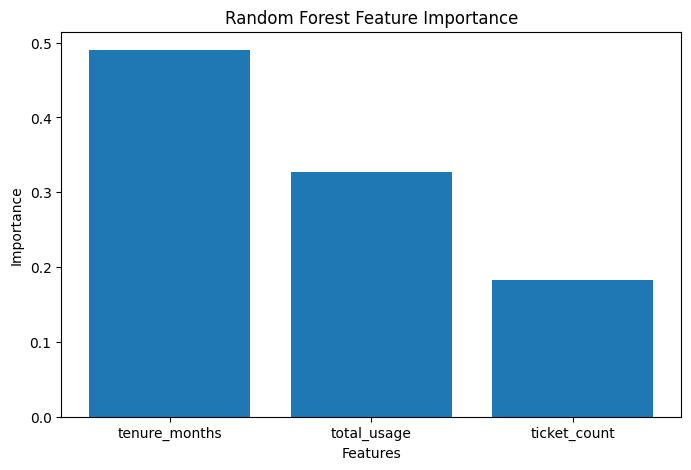

In [28]:
# ==========================================
# RANDOM FOREST FEATURE IMPORTANCE
# ==========================================

import matplotlib.pyplot as plt

# Get feature importance
importance = rf_model.feature_importances_

# Create feature importance table
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("=== RANDOM FOREST FEATURE IMPORTANCE ===")
print(feature_importance)

# Plot
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")

plt.show()

## Conclusion

Random Forest performed better than KNN and Logistic Regression.
The model was used to predict customer churn, and the final predictions
were saved in `final_churn_predictions.csv`.